
# Superpixel Graph Demo


In [5]:

from pathlib import Path
import random, math, os
import numpy as np
import cv2
import matplotlib.pyplot as plt

PRE_ROOT   = Path('../preprocessed')
SPLIT      = 'train'      # 'train' | 'val' | 'test'
N_SAMPLES  = 4
OUT_ROOT   = Path('outputs_demo')

FRANGI_BETA   = 0.5
FRANGI_GAMMA  = 15.0
N_SEGMENTS    = 800
COMPACTNESS   = 0.1
FG_TOP_PCT    = 0.15
BG_LOW_PCT    = 0.15
RING_PX       = 8
LAMBDA_UNARY  = 5.0
BETA_PAIR     = 20.0

_have_skimage = True
_have_maxflow = True
try:
    from skimage.segmentation import slic, find_boundaries
    from skimage.filters import frangi
    from skimage.util import img_as_float
except Exception:
    _have_skimage = False
try:
    import maxflow
except Exception:
    _have_maxflow = False

def ensure_dir(p: Path):
    p.mkdir(parents=True, exist_ok=True)

def list_images(folder: Path, exts=('.png', '.jpg', '.jpeg', '.tif', '.tiff', '.bmp')):
    if not folder.exists(): return []
    return sorted([p for p in folder.iterdir() if p.suffix.lower() in exts])

def save_png(path: Path, img):
    ensure_dir(path.parent)
    cv2.imwrite(str(path), img)

def overlay_mask(gray_u8, mask_u8, alpha=0.35):
    rgb = cv2.cvtColor(gray_u8, cv2.COLOR_GRAY2BGR)
    red = np.zeros_like(rgb); red[..., 2] = 255
    m = (mask_u8 > 0)[..., None]
    out = (rgb * (1 - alpha) + red * alpha).astype(np.uint8)
    out = np.where(m, out, rgb)
    return out

def draw_seed_vis(gray_u8, fg_seed, bg_seed):
    rgb = cv2.cvtColor(gray_u8, cv2.COLOR_GRAY2BGR)
    rg = rgb.copy()
    rg[fg_seed > 0] = (0, 0, 255)
    rg[bg_seed > 0] = (0, 255, 0)
    return cv2.addWeighted(rgb, 0.6, rg, 0.4, 0)

def compute_vesselness(gray_u8, fov_u8):
    g = img_as_float(gray_u8)
    vn = frangi(g, beta=FRANGI_BETA, gamma=FRANGI_GAMMA)
    vn = np.nan_to_num(vn, nan=0.0)
    vn *= (fov_u8 > 0)
    return vn.astype(np.float32)

def build_superpixels(gray_u8, n_segments=N_SEGMENTS, compactness=COMPACTNESS, sigma=0):
    if not _have_skimage:
        labels = np.arange(gray_u8.size, dtype=np.int32).reshape(gray_u8.shape)
        return labels, 1 + labels.max()
    img3 = cv2.cvtColor(gray_u8, cv2.COLOR_GRAY2BGR)
    labels = slic(img3, n_segments=n_segments, compactness=compactness, sigma=sigma, start_label=0, channel_axis=-1)
    return labels.astype(np.int32), int(labels.max() + 1)

def adjacency_from_labels(labels):
    h, w = labels.shape
    adj = [set() for _ in range(labels.max() + 1)]
    L, R = labels[:, :-1], labels[:, 1:]
    m = L != R
    for u, v in zip(L[m], R[m]):
        adj[u].add(int(v)); adj[v].add(int(u))
    U, D = labels[:-1, :], labels[1:, :]
    m = U != D
    for u, v in zip(U[m], D[m]):
        adj[u].add(int(v)); adj[v].add(int(u))
    return [sorted(list(s)) for s in adj]

def select_seeds(vn, fov_u8, labels, fg_top_pct=FG_TOP_PCT, bg_low_pct=BG_LOW_PCT, ring_px=RING_PX):
    in_fov = (fov_u8 > 0)
    vn_f = vn[in_fov]
    if vn_f.size == 0:
        z = np.zeros_like(fov_u8, dtype=np.uint8)
        return z, z
    hi = np.percentile(vn_f, 100 * (1 - fg_top_pct))
    lo = np.percentile(vn_f, 100 * (bg_low_pct))
    fg = ((vn >= hi) & in_fov).astype(np.uint8) * 255
    bg = ((vn <= lo) & in_fov).astype(np.uint8) * 255
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * ring_px + 1, 2 * ring_px + 1))
    inner = cv2.erode((fov_u8 > 0).astype(np.uint8) * 255, k, iterations=1)
    ring = cv2.subtract((fov_u8 > 0).astype(np.uint8) * 255, inner)
    bg = cv2.bitwise_or(bg, ring)
    return fg, bg

def graph_cut_segment(gray_u8, vn, labels, adj, fg_seed, bg_seed, lam_unary=LAMBDA_UNARY, beta_pair=BETA_PAIR):
    H, W = gray_u8.shape
    K = int(labels.max()) + 1

    means_vn = np.zeros(K, dtype=np.float32)
    mean_gray = np.zeros(K, dtype=np.float32)
    for k in range(K):
        m = (labels == k)
        if m.any():
            means_vn[k] = float(vn[m].mean())
            mean_gray[k] = float(gray_u8[m].mean())

    sp_fg = np.zeros(K, dtype=bool)
    sp_bg = np.zeros(K, dtype=bool)
    for k in range(K):
        m = (labels == k)
        if np.any(fg_seed[m] > 0): sp_fg[k] = True
        if np.any(bg_seed[m] > 0): sp_bg[k] = True

    if not _have_maxflow:
        thr = np.percentile(means_vn, 85.0) if means_vn.size > 0 else 0.0
        lab = (means_vn >= thr)
        lab[sp_bg] = False
        lab[sp_fg] = True
        seg = lab[labels].astype(np.uint8) * 255
        seg[(vn <= 0) | (labels < 0)] = 0
        return seg

    g = maxflow.Graph[float](K, K*6)
    nodeids = g.add_nodes(K)
    eps = 1e-6
    for k in range(K):
        v = float(max(0.0, min(1.0, means_vn[k])))
        c_fg = lam_unary * (1.0 - v)
        c_bg = lam_unary * (v)
        if sp_fg[k]: c_fg, c_bg = 0.0, 1e6
        if sp_bg[k]: c_fg, c_bg = 1e6, 0.0
        g.add_tedge(nodeids[k], c_fg + eps, c_bg + eps)

    for u in range(K):
        for v in adj[u]:
            if v <= u: continue
            diff = abs(float(mean_gray[u]) - float(mean_gray[v])) / 255.0
            w = beta_pair * math.exp(-3.0 * (diff ** 2))
            g.add_edge(nodeids[u], nodeids[v], w, w)

    g.maxflow()
    lab = np.array([g.get_segment(nodeids[k]) == 0 for k in range(K)], dtype=bool)  # True=FG
    seg = lab[labels].astype(np.uint8) * 255
    seg[(vn <= 0) | (labels < 0)] = 0
    return seg

print("Config loaded. skimage =", _have_skimage, "| maxflow =", _have_maxflow)


Config loaded. skimage = True | maxflow = False



100_A.png


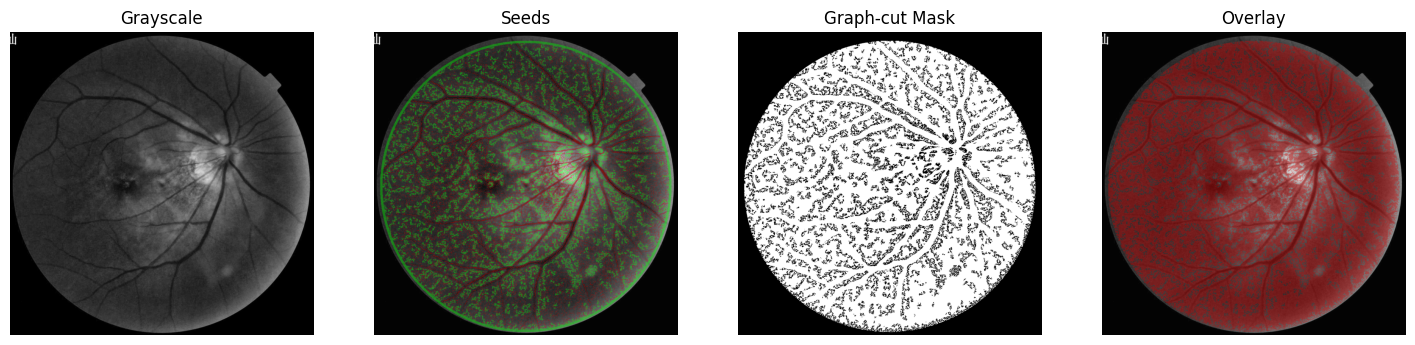


101_A.png


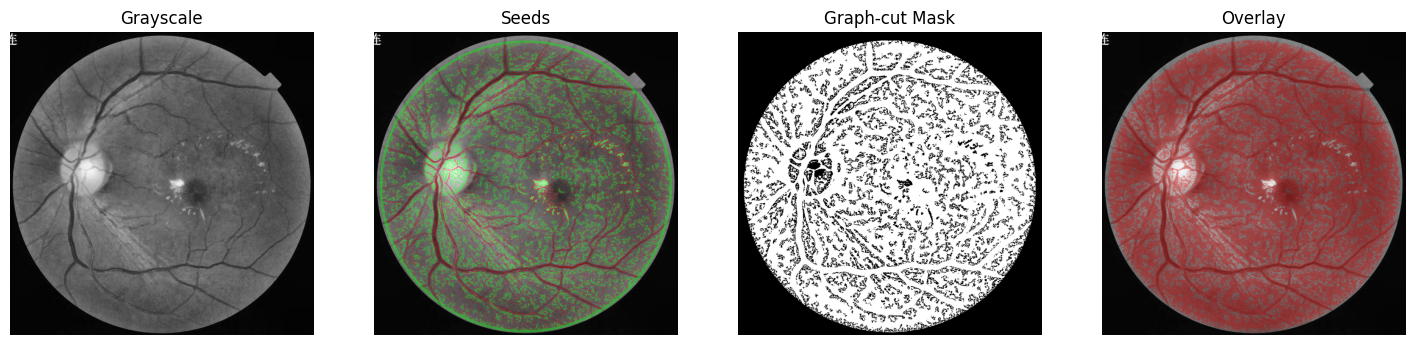


102_A.png


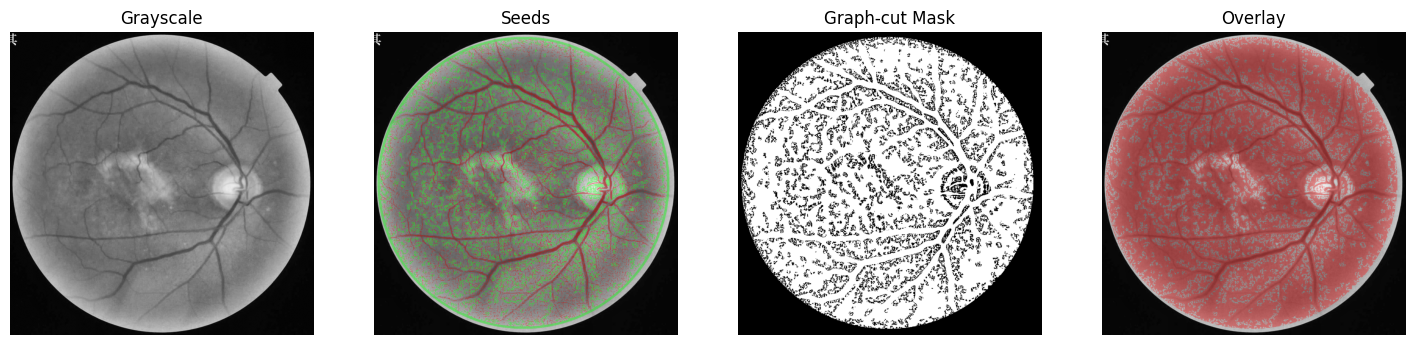


103_A.png


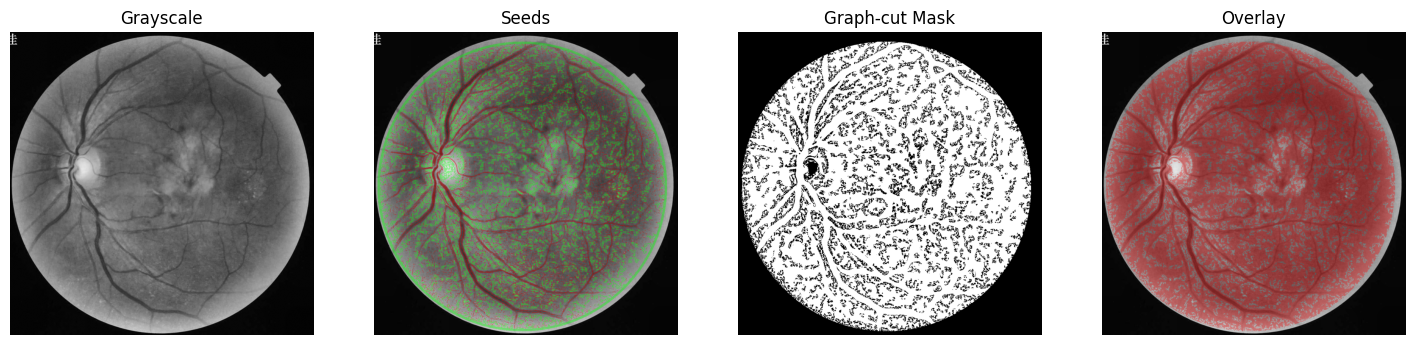

In [8]:

img_dir = PRE_ROOT / SPLIT / 'images'
fov_dir = PRE_ROOT / SPLIT / 'fov_masks'
imgs = list_images(img_dir)
assert len(imgs) > 0, f"No images found in {img_dir}."

random.seed(0)
sample = imgs[:min(N_SAMPLES, len(imgs))]

out_dirs = {
    "masks": OUT_ROOT / SPLIT / "masks",
    "overlays": OUT_ROOT / SPLIT / "overlays",
    "seed_vis": OUT_ROOT / SPLIT / "seed_vis",
    "debug_boundaries": OUT_ROOT / SPLIT / "debug_boundaries",
}
for d in out_dirs.values():
    ensure_dir(d)

for p in sample:
    fov_p = fov_dir / (p.stem + '.png')
    gray_u8 = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
    fov_u8  = cv2.imread(str(fov_p), cv2.IMREAD_GRAYSCALE)
    if gray_u8 is None or fov_u8 is None:
        print("Skip:", p.name, "missing image or FOV")
        continue

    vn = compute_vesselness(gray_u8, fov_u8)
    labels, K = build_superpixels(gray_u8)
    adj = adjacency_from_labels(labels)
    fg_seed, bg_seed = select_seeds(vn, fov_u8, labels)
    seg = graph_cut_segment(gray_u8, vn, labels, adj, fg_seed, bg_seed)

    print(f"\n{p.name}")
    fig, axs = plt.subplots(1, 4, figsize=(18, 4))
    axs[0].imshow(gray_u8, cmap='gray'); axs[0].set_title('Grayscale'); axs[0].axis('off')
    axs[1].imshow(cv2.cvtColor(draw_seed_vis(gray_u8, fg_seed, bg_seed), cv2.COLOR_BGR2RGB)); axs[1].set_title('Seeds'); axs[1].axis('off')
    axs[2].imshow(seg, cmap='gray'); axs[2].set_title('Graph-cut Mask'); axs[2].axis('off')
    axs[3].imshow(cv2.cvtColor(overlay_mask(gray_u8, seg), cv2.COLOR_BGR2RGB)); axs[3].set_title('Overlay'); axs[3].axis('off')
    plt.show()
